# Lab 4: Multiple Linear Regression

## Predicting Exam Score from Multiple Student Features

### Dataset

We use the **Student Clean Dataset**.

For this Multiple Linear Regression lab, we use:

- **Input features (X):** `Study_Hours`, `Attendance`, `Assignments`, `Age`
- **Target (y):** `Exam_Score`

The question we investigate is:

> **Can we predict a student's Exam Score using multiple academic and demographic features?**

### Objectives

- Understand Multiple Linear Regression.
- Implement the OLS solution manually using the Normal Equation.
- Generate predictions and residuals.
- Evaluate the model using MAE, MSE, RMSE, and R².
- Implement the same model using Scikit-Learn.
- Compare the manual implementation with Scikit-Learn `LinearRegression`.
- Verify that both implementations agree up to floating-point precision.


# File Structure

### `mlr_ols_todo.py`

This file contains the **logic and function implementations**:

- `mae()`
- `mse()`
- `r_square()`
- `fit_multiple_lr()`
- `fit_multiple_lr_beta()`
- `predict_multiple_lr()`
- `load_mlr_dataset()`
- `validate_xy()`

### This Notebook

This notebook contains:

- Instructions
- Explanations
- Student Tasks
- Driving code
- Plots
- Scikit-Learn implementation
- Manual vs package comparison

The functions are **not redefined in the notebook**.


# 1. Import Libraries

### Student TODO

Import the required libraries and the provided `mlr_ols_todo` module.

**Do not implement any logic in this cell.**


In [1]:
!pip install -r requirements.txt

zsh:1: command not found: pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
%load_ext autoreload
%autoreload 2

import mlr_ols_todo as mlr

# 2. Load the Dataset

The `load_mlr_dataset()` function is already provided because downloading files is not part of the student implementation.

### Student TODO

Use `mlr.load_mlr_dataset()` to load the clean dataset and display it.

**Do not implement or modify the download logic.**


In [4]:
# Provided: dataset loading is not a student implementation task.
df = mlr.load_mlr_dataset(True)
display(df)


student_clean_dataset.csv already exists. Skipping download.
student_raw_dataset.csv already exists. Skipping download.


,Student_ID,Age,Gender,Department,Study_Hours,Attendance,Assignments,Exam_Score,Result,Grade,Placement,LPA
0,ST001,18,Male,Computer Science,3,98,12,60,Pass,B,Not Placed,0.00
1,ST002,20,Male,Computer Science,1,81,11,44,Pass,D,Not Placed,0.00
2,ST003,19,Male,Computer Science,3,76,9,46,Pass,D,Not Placed,0.00
3,ST004,19,Female,Computer Science,5,100,10,51,Pass,C,Placed,3.39
4,ST005,18,Female,Computer Science,5,68,13,54,Pass,C,Placed,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...
295,ST296,18,Male,Computer Science,8,86,16,74,Pass,A,Not Placed,0.00
296,ST297,19,Female,Computer Science,9,80,19,92,Pass,A+,Placed,19.43
297,ST298,18,Male,Mechanical,9,81,20,94,Pass,A+,Placed,14.97
298,ST299,19,Male,Computer Science,6,82,18,82,Pass,A+,Placed,7.40


# 3. Check Dataset Size

### Student TODO

Inspect:

- number of rows
- number of columns

Use the DataFrame shape.


In [5]:
# Inspect the dataset shape.
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Dataset shape: (300, 12)
Number of rows: 300
Number of columns: 12


# 4. Select X and y

For this lab:

- `Study_Hours`, `Attendance`, `Assignments`, and `Age` are the independent/input variables.
- `Exam_Score` is the dependent/target variable.

### Student TODO

Create `X` and `y` from the required columns.

Then inspect the input and target sizes.

**Focus:** Understand how multiple input variables are combined into the feature matrix `X`, and verify that `X` and `y` contain the same number of observations.


In [6]:
# Select the four input features and the target.
feature_names = ['Study_Hours', 'Attendance', 'Assignments', 'Age']
X = df[feature_names].to_numpy(dtype=float)
y = df['Exam_Score'].to_numpy(dtype=float)

# Provided: validation helps you inspect input/target sizes and data quality.
mlr.validate_xy(X, y)

print("Features:", feature_names)
print("Target variable: Exam_Score")
print("Number of observations:", len(df))


X shape: (300, 4)
y shape: (300,)

X data type:
<class 'numpy.ndarray'> float64

y data type:
<class 'numpy.ndarray'> float64

Missing values:
X: 0
y: 0

Number of observations:
X: 300
y: 300

X and y validation successful.
Features: ['Study_Hours', 'Attendance', 'Assignments', 'Age']
Target variable: Exam_Score
Number of observations: 300


# 5. Correlation Heatmap

The plotting code is provided for reference.

### Student TODO

No implementation is required in this section.

Use the provided visualization to understand the relationships among the numeric variables.



Correlation Matrix


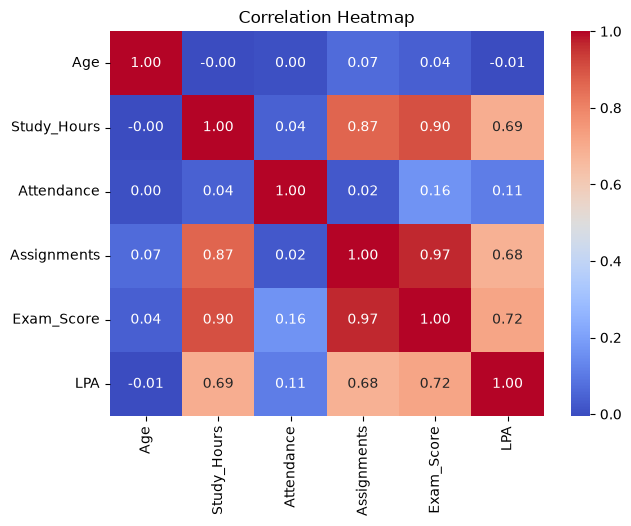

In [7]:
# Provided visualization — no student implementation required.
print('\nCorrelation Matrix')
numeric_df = df.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


# 6. Fit Multiple Linear Regression Using the Normal Equation

The manual model uses the OLS Normal Equation:

$$
\beta = (X^T X)^{-1}X^T y
$$

An intercept column of ones is added inside the supplied function.

### Student TODO

Implement `fit_multiple_lr_beta()` in `mlr_ols_todo.py`.

Then use it to calculate the coefficient vector.

The coefficient vector should contain:

1. Intercept
2. `Study_Hours` coefficient
3. `Attendance` coefficient
4. `Assignments` coefficient
5. `Age` coefficient

**Core logic to implement:** construct the matrix terms in the Normal Equation and calculate the OLS coefficient vector.


In [8]:
# Use the implementation of fit_multiple_lr_beta().
beta = mlr.fit_multiple_lr_beta(X, y)

print('Manual OLS coefficients')
print('Intercept:', beta[0])
for feature, coefficient in zip(feature_names, beta[1:]):
    print(f'{feature}: {coefficient:.6f}')


NameError: name 'x' is not defined

# 7. Verify the Two Manual OLS Function Forms

The module contains two forms of the same Normal Equation:

- `fit_multiple_lr()` — compact form
- `fit_multiple_lr_beta()` — broken-down matrix form

### Student TODO

Implement both functions in `mlr_ols_todo.py`.

Then use the compact implementation to verify that both coefficient vectors match.


In [ ]:
# Use the compact implementation.
beta_one_liner = mlr.fit_multiple_lr(X, y)

print('Coefficient vectors match:', np.allclose(beta_one_liner, beta))
print('Maximum absolute coefficient difference:', np.max(np.abs(beta_one_liner - beta)))


# 8. Generate Predictions

The prediction equation for Multiple Linear Regression is:

$$
\hat{y}=X\beta
$$

### Student TODO

Implement `predict_multiple_lr()` in `mlr_ols_todo.py`.

Then use it to generate the predicted Exam Score for every observation.

Create the Actual vs Predicted DataFrame using the provided notebook code structure.

**Core logic to implement:** add the intercept column and multiply the feature matrix by the learned coefficient vector.


In [ ]:
# Use the implementation of predict_multiple_lr().
y_pred = mlr.predict_multiple_lr(X, beta)

manual_results = pd.DataFrame({
    'Actual Exam Score': y,
    'Manual OLS Prediction': y_pred
})
display(manual_results)


# 9. Residuals

A residual is:

$$
e_i=y_i-\hat{y}_i
$$

### Student TODO

Calculate the residuals from actual and predicted values.

Then use the provided plot to inspect them.

**Core logic to understand:** residual = actual value − predicted value.

No plotting implementation is required.


In [ ]:
# Calculate residuals.
manual_residuals = y - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, manual_residuals)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot — Manual OLS')
plt.grid(True)
plt.show()


# 10. Mean Squared Error (MSE)

$$
MSE=\frac{1}{n}\sum(y_i-\hat{y}_i)^2
$$

### Student TODO

Implement `mse()` in `mlr_ols_todo.py`.

Then use it to calculate MSE.

**Core logic to implement:** calculate the prediction errors, square them, and take their mean.


In [ ]:
# Use your implementation of mse().
mse_value = mlr.mse(y, y_pred)

print("MSE:", mse_value)


# 11. Mean Absolute Error (MAE)

$$
MAE=\frac{1}{n}\sum|y_i-\hat{y}_i|
$$

### Student TODO

Implement `mae()` in `mlr_ols_todo.py`.

Then use it to calculate MAE.

**Core logic to implement:** calculate the absolute prediction errors and take their mean.


In [ ]:
# Use your implementation of mae().
mae_value = mlr.mae(y, y_pred)

print("MAE:", mae_value)


# 12. Root Mean Squared Error (RMSE)

$$
RMSE=\sqrt{MSE}
$$

### Student TODO

Calculate RMSE from the MSE produced by your implementation.

**Core logic:** RMSE is the square root of MSE.


In [ ]:
# Calculate RMSE from your MSE.
rmse_value = np.sqrt(mse_value)

print("RMSE:", rmse_value)


# 13. R² Score

$$
R^2=1-\frac{SS_{residual}}{SS_{total}}
$$

where:

$$
SS_{total}=\sum(y_i-\bar{y})^2
$$

### Student TODO

Implement `r_square()` in `mlr_ols_todo.py`.

Then use it to calculate R².

**Core logic to implement:** calculate total sum of squares, residual sum of squares, and apply the R² formula.


In [ ]:
# Use your implementation of r_square().
r2_value = mlr.r_square(y, y_pred)

print("R²:", r2_value)


# 14. Actual vs Predicted

The plotting code is provided.

### Student TODO

No plotting implementation is required.

Use the provided visualization to interpret actual versus predicted values.


In [ ]:
# Provided visualization — no student implementation required.
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred)
min_value = min(y.min(), y_pred.min())
max_value = max(y.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linewidth=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title(f'Actual vs Predicted — Manual OLS (R² = {r2_value:.4f})')
plt.grid(True)
plt.show()


# 15. Manual Model Summary

### Student TODO

Use the values returned by your implemented functions to produce the manual model summary.

No comparison with Scikit-Learn is required in this section.


In [ ]:
# Provided summary structure.
manual_summary = pd.DataFrame({
    'Measure': ['Intercept', *feature_names, 'MAE', 'MSE', 'RMSE', 'R²'],
    'Manual OLS': [beta[0], *beta[1:], mae_value, mse_value, rmse_value, r2_value]
})
display(manual_summary)


# 16. Multiple Linear Regression Using Scikit-Learn

Use the same four input features and `Exam_Score`.

### Student TODO

Prepare the input matrix and target in the format required by Scikit-Learn.

**Focus:** Understand the number of observations, number of features, and shape of the input matrix before training.


In [ ]:
# Prepare X and Y in the format required by Scikit-Learn.
X_sklearn = df[feature_names]
Y_sklearn = df['Exam_Score']

print("X shape:", X_sklearn.shape)
print("Y shape:", Y_sklearn.shape)


# 17. Train the Scikit-Learn Model

### Student TODO

Create a `LinearRegression` object and train it using `X_sklearn` and `Y_sklearn`.

**Core logic:** understand the model-training step and how the input matrix and target vector are passed to `fit()`.


In [ ]:
# Create and train the Scikit-Learn LinearRegression model.
sklearn_model = LinearRegression()
sklearn_model.fit(X_sklearn, Y_sklearn)


# 18. Scikit-Learn Coefficients

### Student TODO

Read and print the intercept and the coefficient learned for each feature.

No manual comparison is required here.


In [ ]:
# Read the learned intercept and coefficients.
sklearn_intercept = sklearn_model.intercept_
sklearn_coefficients = sklearn_model.coef_

print('Scikit-Learn coefficients')
print('Intercept:', sklearn_intercept)
for feature, coefficient in zip(feature_names, sklearn_coefficients):
    print(f'{feature}: {coefficient:.6f}')


# 19. Scikit-Learn Predictions

### Student TODO

Use the trained Scikit-Learn model to generate predictions.

No manual comparison is required here.


In [ ]:
# Generate predictions using the trained Scikit-Learn model.
sklearn_pred = sklearn_model.predict(X_sklearn)

sklearn_results = pd.DataFrame({
    'Actual Exam Score': Y_sklearn,
    'Scikit-Learn Prediction': sklearn_pred
})
display(sklearn_results)


# 20. Scikit-Learn Residuals and Metrics

### Student TODO

Calculate:

- residuals
- MAE
- MSE
- RMSE
- R²

using the Scikit-Learn functions provided in the notebook.

The plotting portion is provided and is not a student implementation task.


In [ ]:
# Calculate Scikit-Learn residuals and metrics.
sklearn_residuals = Y_sklearn.to_numpy() - sklearn_pred
sklearn_mae = mean_absolute_error(Y_sklearn, sklearn_pred)
sklearn_mse = mean_squared_error(Y_sklearn, sklearn_pred)
sklearn_rmse = np.sqrt(sklearn_mse)
sklearn_r2 = r2_score(Y_sklearn, sklearn_pred)

print("MAE :", sklearn_mae)
print("MSE :", sklearn_mse)
print("RMSE:", sklearn_rmse)
print("R²  :", sklearn_r2)

# Provided visualization — no student implementation required.
plt.figure(figsize=(8, 6))
plt.scatter(sklearn_pred, sklearn_residuals)
plt.axhline(0, color='red', linewidth=2)
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot — Scikit-Learn')
plt.grid(True)
plt.show()


# 21. Manual vs Scikit-Learn Comparison

Both approaches use the same data and solve the same Multiple Linear Regression problem.

### Student TODO

No manual comparison is required.

The comparison is provided so you can verify whether your implementation produces the expected results.


In [ ]:
# Provided comparison — no manual comparison implementation required.
comparison = pd.DataFrame({
    'Measure': ['Intercept', *feature_names, 'MAE', 'MSE', 'RMSE', 'R²'],
    'Manual OLS': [beta[0], *beta[1:], mae_value, mse_value, rmse_value, r2_value],
    'Scikit-Learn': [sklearn_intercept, *sklearn_coefficients, sklearn_mae, sklearn_mse, sklearn_rmse, sklearn_r2]
})
display(comparison)


# 22. Compare Predictions

### Student TODO

No manual comparison is required.

The provided cell displays the predictions from both approaches for verification.


In [ ]:
# Provided prediction comparison — no manual comparison implementation required.
prediction_comparison = pd.DataFrame({
    'Actual Exam Score': Y_sklearn,
    'Manual Prediction': y_pred,
    'Scikit-Learn Prediction': sklearn_pred
})
display(prediction_comparison)


# 23. Final Verification

### Student TODO

Run the provided verification.

Use the results to confirm that your implemented functions and the Scikit-Learn model produce matching results up to normal floating-point precision.

Do not add a separate comparison implementation.


In [ ]:
# Provided final verification — no student implementation required.
print('Intercept matches:', np.isclose(beta[0], sklearn_intercept))
print('Coefficients match:', np.allclose(beta[1:], sklearn_coefficients))
print('Predictions match:', np.allclose(y_pred, sklearn_pred))
print('MAE matches:', np.isclose(mae_value, sklearn_mae))
print('MSE matches:', np.isclose(mse_value, sklearn_mse))
print('RMSE matches:', np.isclose(rmse_value, sklearn_rmse))
print('R² matches:', np.isclose(r2_value, sklearn_r2))


# Final Questions

Answer briefly:

1. What does the intercept represent in Multiple Linear Regression?
2. What does a regression coefficient represent when the other features are held constant?
3. What is a residual?
4. What does a positive residual mean?
5. What does a negative residual mean?
6. What does MAE measure?
7. What does MSE measure?
8. Why is RMSE the square root of MSE?
9. What does R² tell us?
10. Why should manual OLS and Scikit-Learn produce almost identical results?
11. What is the advantage of implementing the Normal Equation manually before using a package?
12. Why do we add a column of ones to the feature matrix?
13. Why do the manual and Scikit-Learn coefficient vectors have the same feature order?
14. What does it mean if the absolute difference between the two implementations is very small?

---

## Student Submission

Submit:

1. The completed `mlr_ols_todo.py` file.
2. The completed Lab 4 notebook.
3. Answers to the final questions.

**Student implementation focus:** core regression logic, prediction logic, error calculations, input/target sizes and shapes, and Scikit-Learn model training. Plotting, file downloading, and manual comparison are provided and are not independent implementation tasks.


## Final Questions — Answers

1. **Intercept:** The predicted `Exam_Score` when all input features are zero.
2. **Regression coefficient:** The expected change in `Exam_Score` for a one-unit increase in that feature, while the other features are held constant.
3. **Residual:** The difference between the actual value and predicted value: `y - ŷ`.
4. **Positive residual:** The actual score is higher than the predicted score.
5. **Negative residual:** The actual score is lower than the predicted score.
6. **MAE:** The average absolute prediction error.
7. **MSE:** The average squared prediction error.
8. **Why RMSE is √MSE:** Taking the square root returns the error to the same units as the target variable.
9. **R²:** The proportion of variation in the target explained by the regression model.
10. **Why manual OLS and Scikit-Learn agree:** Both solve the same linear regression problem using the same data and feature order; differences should mainly be floating-point numerical precision.
11. **Advantage of manual Normal Equation:** It shows how OLS works mathematically instead of treating the regression algorithm as a black box.
12. **Column of ones:** It provides the constant term needed to estimate the intercept.
13. **Same feature order:** Each coefficient must correspond to the same feature position in both implementations for the models to be compared correctly.
14. **Very small absolute difference:** The two implementations are effectively producing the same result, with the difference attributable to numerical precision.
